# PySlyde tutorial: from a whole-slide image to tiles and features

This notebook walks through the main PySlyde workflow end to end:

1. open a whole-slide image (WSI) and inspect it,
2. read annotations in every supported format,
3. generate annotation masks and extract regions,
4. detect tissue,
5. tile the slide, filter and sample tiles,
6. stain-normalise tiles,
7. extract deep features (and reduce them with PCA),
8. save tiles, masks and features (disk / LMDB), and stitch tiles back together.

**Data.** It runs on the PySlyde [example dataset](https://pyslyde.readthedocs.io/en/latest/example_data.html):
`CMU-1-Small-Region.svs` from the OpenSlide test data (CC0, 1.9 MB, downloaded once and
checksum-verified) with *synthetic* `tissue` / `epithelium` annotations shipped with PySlyde.
To run it on your own data, set the environment variable `PYSLYDE_DATA_DIR` to a folder
containing `wsi/` and `annotations/` before starting Jupyter.

Install PySlyde with its optional extras (`pip install "pyslyde[all]"`), plus the OpenSlide
library (see the installation guide). The whole notebook runs in about a minute on a laptop CPU.
The only extra download is the torchvision ResNet-18 weights used in the feature-extraction section.

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ["jpeg"]
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import openslide

import pyslyde
from pyslyde import Annotations, Slide, Stitching, WSIParser
from pyslyde.datasets import example_data_dir
from pyslyde.masks.level0 import Level0Mask
from pyslyde.normalization.factory import make_normalizer
from pyslyde.util import filters
from pyslyde.util.utilities import (
    TissueDetect, calculate_std_mean, calculate_weights, coord_to_name, mask2rgb,
)

plt.rcParams["figure.dpi"] = 80

print("PySlyde", pyslyde.__version__, "| OpenSlide", openslide.__library_version__)

PySlyde 0.1.0 | OpenSlide 4.0.1


In [2]:
DATA_DIR = example_data_dir()            # honours $PYSLYDE_DATA_DIR
WSI_PATH = next((DATA_DIR / "wsi").iterdir())
ANN_DIR = DATA_DIR / "annotations"

OUTPUT_DIR = Path("tutorial_output")    # everything this notebook writes goes here
OUTPUT_DIR.mkdir(exist_ok=True)

print("slide:", WSI_PATH.name)
print("annotations:", sorted(p.name for p in ANN_DIR.iterdir()))

slide: CMU-1-Small-Region.svs
annotations: ['example.csv', 'example.geojson', 'example_asap.xml', 'example_custom.json', 'example_imagej.xml', 'example_qupath.json']


## 1. Whole-slide images with `Slide`

`Slide` subclasses `openslide.OpenSlide`, so all OpenSlide properties and methods are available,
plus annotation masks, borders and region extraction.

dimensions (w, h): (2220, 2967)
pyramid levels:    1 ((2220, 2967),)
objective power:   20
microns per pixel: 0.499


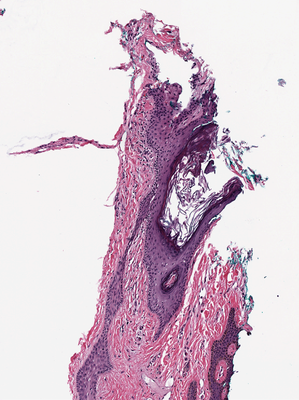

In [3]:
slide = Slide(str(WSI_PATH))
print("dimensions (w, h):", slide.dims)
print("pyramid levels:   ", slide.level_count, slide.level_dimensions)
print("objective power:  ", slide.properties.get(openslide.PROPERTY_NAME_OBJECTIVE_POWER))
print("microns per pixel:", slide.properties.get(openslide.PROPERTY_NAME_MPP_X))
slide.get_thumbnail((400, 400))

## 2. Annotations in six formats

`Annotations` parses QuPath, ImageJ, ASAP, GeoJSON, CSV and a custom JSON format into the same
in-memory representation: `{label: [polygon, ...]}` with level-0 pixel coordinates.
The example dataset contains the same polygons in every format.

In [4]:
sources = {
    "geojson": "example.geojson",
    "csv": "example.csv",
    "qupath": "example_qupath.json",
    "asap": "example_asap.xml",
    "imagej": "example_imagej.xml",
    "json": "example_custom.json",
}
anns = {src: Annotations(str(ANN_DIR / fname), source=src) for src, fname in sources.items()}

for src, a in anns.items():
    summary = {label: len(polys) for label, polys in a.annotations.items()}
    print(f"{src:8s} polygons per label: {summary}")

geojson  polygons per label: {'tissue': 1, 'epithelium': 3}
csv      polygons per label: {'tissue': 1, 'epithelium': 3}
qupath   polygons per label: {'tissue': 1, 'epithelium': 3}
asap     polygons per label: {'tissue': 1, 'epithelium': 3}
imagej   polygons per label: {'tissue': 1, 'epithelium': 3}
json     polygons per label: {'tissue': 1, 'epithelium': 3}


Each label gets a stable integer ID, used as the pixel value in masks:

In [5]:
annotations = anns["geojson"]
annotations.class_key

{'epithelium': 1, 'tissue': 2}

Labels can be renamed, and annotations exported as a table or another format:

In [6]:
renamed = Annotations(str(ANN_DIR / "example.geojson"), source="geojson")
renamed.rename_labels({"epithelium": "epi"})
print(renamed.class_key)

annotations.df.head()

{'epithelium': 1, 'tissue': 2}


,label,polygon_id,vertex_id,x,y
0,tissue,0,0,1070,78
1,tissue,0,1,1066,110
2,tissue,0,2,1056,112
3,tissue,0,3,1046,142
4,tissue,0,4,976,144


In [7]:
annotations.save_csv(str(OUTPUT_DIR / "annotations.csv"), overwrite=True)
annotations.save_geojson(str(OUTPUT_DIR / "annotations.geojson"), overwrite=True)
sorted(p.name for p in OUTPUT_DIR.iterdir())

['annotations.csv', 'annotations.geojson']

## 3. Annotation masks and regions

Attach the annotations to the slide, then rasterise them. `generate_mask` takes either an output
`size` (width, height) or a pyramid `level`.

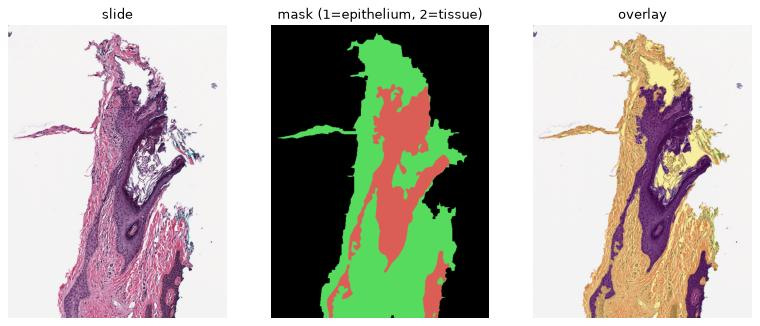

In [8]:
slide = Slide(str(WSI_PATH), annotations=annotations)
mask = slide.generate_mask(size=(555, 742))

thumb = np.array(slide.get_thumbnail((555, 742)).convert("RGB"))
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(thumb); axes[0].set_title("slide")
axes[1].imshow(mask2rgb(mask)); axes[1].set_title("mask (1=epithelium, 2=tissue)")
axes[2].imshow(thumb); axes[2].imshow(np.ma.masked_equal(mask, 0), alpha=0.4, cmap="viridis")
axes[2].set_title("overlay")
for ax in axes: ax.axis("off")
plt.show()

Restrict a mask to some labels (by name or ID), and get the bounding border of the annotations:

In [9]:
epithelium = slide.generate_mask(size=(555, 742), labels=["epithelium"])
print("epithelium pixels:", int((epithelium > 0).sum()))
print("annotation border [(x_min, x_max), (y_min, y_max)]:", slide.get_border())

epithelium pixels: 53060
annotation border [(x_min, x_max), (y_min, y_max)]: [(0, 2090), (0, 2967)]


`generate_region` returns an RGB region and its aligned annotation mask (level-0 coordinates):

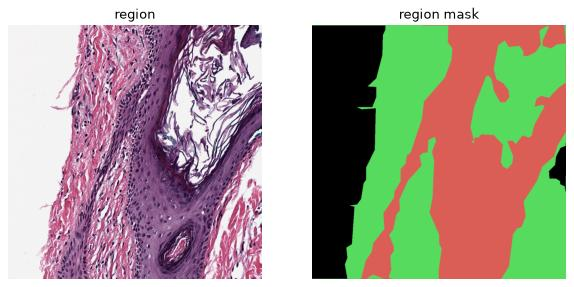

In [10]:
region, region_mask = slide.generate_region(level=0, x=(600, 1600), y=(1200, 2200))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(region); axes[0].set_title("region")
axes[1].imshow(mask2rgb(region_mask)); axes[1].set_title("region mask")
for ax in axes: ax.axis("off")
plt.show()

Save the mask, a visualisation and metadata in one call:

In [11]:
slide.save(str(OUTPUT_DIR / "slide"), size=(555, 742), overwrite=True)

[ WARN:0@5.754] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


{'mask': 'tutorial_output/slide/masks/CMU-1-Small-Region.npy',
 'vis': 'tutorial_output/slide/vis/CMU-1-Small-Region.png',
 'meta': 'tutorial_output/slide/meta/CMU-1-Small-Region.json'}

### Connected tissue components

`detect_components` finds separate pieces of tissue at a given pyramid level and returns an image
and a level-0 bounding box for each. This slide has a single level, so we use `level=0`.

component borders: [[(1640, 1888), (1081, 1412)], [(69, 1888), (83, 2967)]]


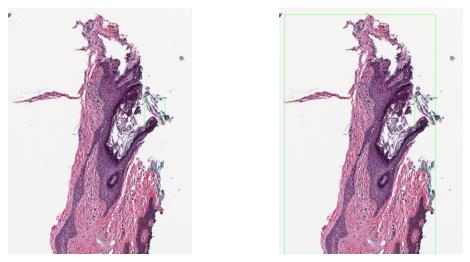

In [12]:
components, borders = slide.detect_components(level=0, num_component=2)
print("component borders:", borders)
fig, axes = plt.subplots(1, len(components), figsize=(4 * len(components), 4))
for ax, comp in zip(np.atleast_1d(axes), components):
    ax.imshow(comp); ax.axis("off")
plt.show()

## 4. Tissue detection

`TissueDetect` finds tissue without annotations. It works on a path, an `OpenSlide` object or a
NumPy image.

tissue fraction: 0.282 | border: ((0, 2124), (0, 2967))


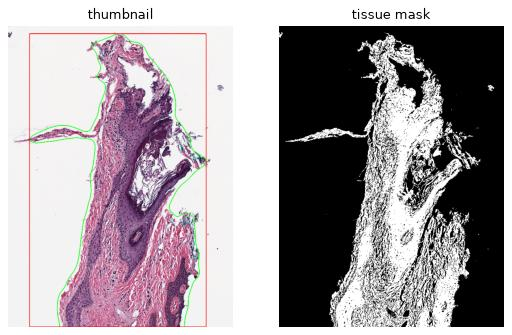

In [13]:
detector = TissueDetect(str(WSI_PATH))
tissue_mask = detector.detect_tissue()        # full-resolution binary mask
tissue_border = detector.border()             # ((x_min, x_max), (y_min, y_max))
print("tissue fraction:", round(float(tissue_mask.mean()), 3), "| border:", tissue_border)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(cv2.resize(detector.tissue_thumbnail, (555, 742))); axes[0].set_title("thumbnail")
axes[1].imshow(cv2.resize(tissue_mask, (555, 742)), cmap="gray"); axes[1].set_title("tissue mask")
for ax in axes: ax.axis("off")
plt.show()

## 5. Tiling with `WSIParser`

`WSIParser` lays a grid of tiles over a border (here the annotation border) at a given level.
Tile coordinates are level-0 `(x, y)` of the top-left corner.

tiles: 88


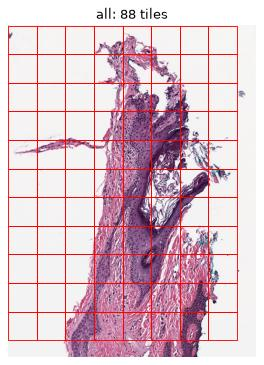

In [14]:
TILE = 256
parser = WSIParser(slide=slide, tile_dim=TILE, border=slide.get_border(), level=0)
# edge_cases=True drops tiles that would extend past the border / slide edge
print("tiles:", parser.tiler(stride=TILE, edge_cases=True))


def show_tiles(parser, title):
    scale = 555 / slide.dims[0]
    fig, ax = plt.subplots(figsize=(4, 5.4))
    ax.imshow(thumb)
    for x, y in parser.tiles:
        ax.add_patch(mpatches.Rectangle((x * scale, y * scale), TILE * scale, TILE * scale,
                                        fill=False, edgecolor="red", linewidth=0.8))
    ax.set_title(f"{title}: {parser.number} tiles"); ax.axis("off")
    plt.show()


show_tiles(parser, "all")

### Filtering tiles

Keep tiles that are mostly tissue with `filter_by_mask`, which takes any whole-slide mask
(here the tissue mask, wrapped as a level-0 mask) and the labels to keep:

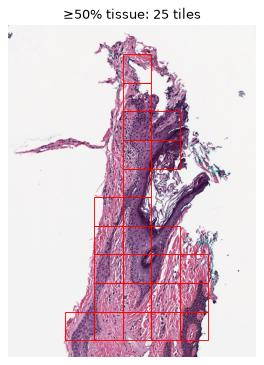

In [15]:
tissue = Level0Mask(tissue_mask.astype(np.uint8))
parser.filter_by_mask(tissue, labels=1, threshold=0.5)
show_tiles(parser, "≥50% tissue")

Or with any function that returns `True` for tiles to drop, e.g. bright background tiles:

In [16]:
parser.filter_by_func(filters.tile_intensity, threshold=220)
print("after intensity filter:", parser.number)

after intensity filter: 25


Look at a few tiles:

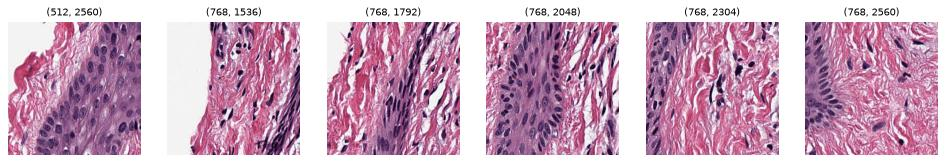

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(15, 2.6))
for ax, ((x, y), tile) in zip(axes, parser.extract_tiles()):
    ax.imshow(tile); ax.set_title(f"({x}, {y})", fontsize=9); ax.axis("off")
plt.show()

### Tile-level annotation masks

`extract_masks` returns, for each tile, the matching crop of a whole-slide mask, e.g. the
annotation mask for segmentation training data:

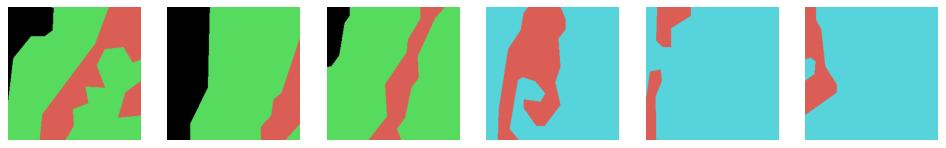

In [18]:
annotation_mask = Level0Mask(slide.generate_mask(level=0).astype(np.uint8))
fig, axes = plt.subplots(1, 6, figsize=(15, 2.6))
for ax, ((x, y), m) in zip(axes, parser.extract_masks(annotation_mask)):
    ax.imshow(mask2rgb(m) if m.max() > 0 else m, cmap="gray"); ax.axis("off")
plt.show()

## 6. Stain normalisation

PySlyde implements Macenko, Reinhard and Vahadane normalisation. Fit a normaliser on a target
tile, pass it to `WSIParser`, then request `normalize=True` when extracting tiles.

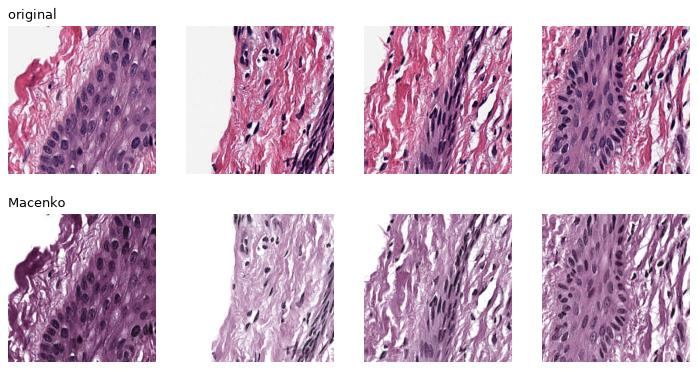

In [19]:
target_tile = next(parser.extract_tiles())[1]
normalizer = make_normalizer("macenko").fit(target_tile)

norm_parser = WSIParser(slide=slide, tile_dim=TILE, border=slide.get_border(), level=0,
                        stain_normalizer=normalizer)
norm_parser.tiles = parser.tiles[:4]

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
for i, (((x, y), raw), (_, norm)) in enumerate(zip(norm_parser.extract_tiles(),
                                                   norm_parser.extract_tiles(normalize=True))):
    axes[0, i].imshow(raw); axes[1, i].imshow(norm)
    axes[0, i].axis("off"); axes[1, i].axis("off")
axes[0, 0].set_title("original", loc="left"); axes[1, 0].set_title("Macenko", loc="left")
plt.show()

## 7. Feature extraction

`extract_features` runs a model on every tile and yields `((x, y), feature_vector)`.
Torchvision models (`resnet18`, `resnet50`, `vgg16`) download ImageNet weights on first use;
pathology foundation models (`uni`, `uni2`, `virchow`, `virchow2`, `gigapath`, `hoptimus0`,
`hoptimus1`, `phikon`, `phikon2`, `transpath`, `pathfm`) are also supported, several of which are
gated on Hugging Face and need a token.

In [20]:
parser.sample_tiles(n=24, seed=0)           # keep the example fast
features = dict(parser.extract_features(model_name="resnet18"))
coords = np.array(list(features))
X = np.stack(list(features.values()))
print("feature matrix:", X.shape)

feature matrix: (24, 512)


Reduce the features with PCA (`pyslyde.util.pca`) and look at the first two components:

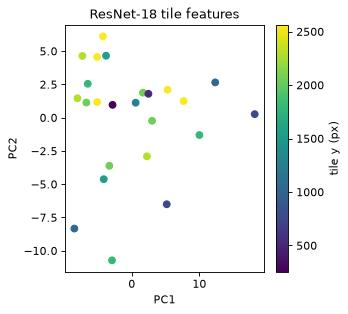

In [21]:
from pyslyde.util.pca import PCAConfig, fit_pca_from_parser

pca = fit_pca_from_parser(iter(features.items()), config=PCAConfig(n_components=2, method="full"))
Z = pca.transform(X)
plt.figure(figsize=(4, 4))
plt.scatter(Z[:, 0], Z[:, 1], c=coords[:, 1], cmap="viridis")
plt.colorbar(label="tile y (px)"); plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("ResNet-18 tile features")
plt.show()

## 8. Saving outputs

Tiles can be written as PNG files, to LMDB or RocksDB, and features as `.npy` files:

In [22]:
parser.save_tiles(tile_path=str(OUTPUT_DIR / "tiles"), label_csv=True)
parser.to_lmdb(parser.extract_tiles(), db_path=str(OUTPUT_DIR / "tiles.lmdb"), map_size=1024**3)
parser.feat_to_disk(parser.extract_features(model_name="resnet18"), path=str(OUTPUT_DIR / "features"))

print(len(list((OUTPUT_DIR / "tiles").iterdir())), "tile PNGs |",
      len(list((OUTPUT_DIR / "features").iterdir())), "feature files")

db path and map_size: tutorial_output/tiles.lmdb 1073741824
Beginning writing to lmdb ...
Finished writing to lmdb (24 items).
Beginning writing to disk...


Finished writing to disk (24 items).
24 tile PNGs | 24 feature files


Channel statistics of the saved tiles, e.g. for input normalisation when training a model:

In [23]:
mean, std = calculate_std_mean(str(OUTPUT_DIR / "tiles"))

total number pixels: 1572864
mean: [0.58437588 0.44534164 0.64227313], std: [0.21058063 0.26318875 0.24129613]


### Tile masks and class weights

Save the annotation mask of each tile (named by its coordinates, like the tile images), then
compute inverse-frequency class weights for segmentation training:

In [24]:
mask_dir = OUTPUT_DIR / "tile_masks"
mask_dir.mkdir(exist_ok=True)
for (x, y), m in parser.extract_masks(annotation_mask):
    cv2.imwrite(str(mask_dir / f"{coord_to_name(x, y)}.png"), m.astype(np.uint8))

weights = calculate_weights(str(OUTPUT_DIR / "tile_masks"), num_cls=len(annotations.class_key) + 1)
weights

Calculating weights


[np.float64(0.02708880106608073), np.float64(0.4008992513020833), np.float64(0.5720119476318359)]
[np.float64(36.915624193207684), np.float64(2.494392286221771), np.float64(1.7482152324615954)]


[np.float64(36.915624193207684),
 np.float64(2.494392286221771),
 np.float64(1.7482152324615954)]

## 9. Stitching tiles back together

`Stitching` reassembles saved tiles (whose filenames encode their coordinates) into one image.
With a contiguous grid of tiles this reconstructs the tiled area of the slide:

completeness: 1.0


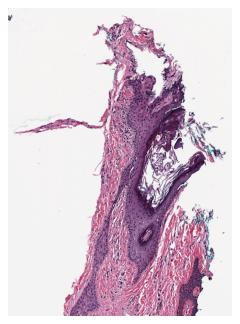

In [25]:
grid = WSIParser(slide=slide, tile_dim=TILE, border=slide.get_border(), level=0)
grid.tiler(stride=TILE, edge_cases=True)
grid.save_tiles(tile_path=str(OUTPUT_DIR / "grid_tiles"))

stitcher = Stitching(str(OUTPUT_DIR / "grid_tiles"), slide=slide, level=0)
canvas = stitcher.stitch(size=(512, 704))      # OpenCV channel order (BGR)
canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
print("completeness:", stitcher.completeness())
plt.figure(figsize=(5, 5)); plt.imshow(canvas); plt.axis("off"); plt.show()

## Next steps

* [Quick Start](https://pyslyde.readthedocs.io/en/latest/quickstart.html) - the same workflow as short code snippets
* [API reference](https://pyslyde.readthedocs.io/en/latest/api/index.html)
* [Mask to polygons with GeoPandas](geopandas_polygons.ipynb) - convert masks to GeoPandas polygons